In [4]:
import pandas as pd
import gzip

In [7]:
meta_df = pd.read_json(
    "C:/Users/affaa/OneDrive/Desktop/CDAC_PROJECT/raw_data/meta_Sports_and_Outdoors.jsonl",
    lines=True,
    nrows=1000
)

In [8]:
meta_df.head()

,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together,subtitle,author
0,None,Sure-Grip Zombie Wheels Low 59mm 4 Pack,4.5,84,"[Pre-packaged in sets of 4, Low profile 59mm x...",[All Zombie wheels are made in the USA. Zombie...,55.00,[{'thumb': 'https://m.media-amazon.com/images/...,[],Sure-Grip,"[Sports & Outdoors, Sports, Skates, Skateboard...",{'Item Package Dimensions L x W x H': '4.49 x ...,B01HDXC8AG,NaN,NaN,NaN
1,None,USGI Wet Weather Bag (Fоur Paсk),4.2,14,[],[Wet Wetaher bag US Military 4 pack],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[{'title': 'USGI Waterproof Bag | Willy Peter ...,USGI,"[Sports & Outdoors, Sports, Boating & Sailing,...",{'Best Sellers Rank': {'Sports & Outdoors': 96...,B07R5BQ4YD,NaN,NaN,NaN
2,None,NHL San Jose Sharks Team Logo Post Earrings,4.5,28,"[100% Synthetic, Imported, Adorable Post Earri...",[Complete your game day outfit with these cute...,18.99,[{'thumb': 'https://m.media-amazon.com/images/...,[],Aminco,"[Sports & Outdoors, Fan Shop, Jewelry & Watche...",{'Item Package Dimensions L x W x H': '2.5 x 2...,B003K8GZ7G,NaN,NaN,NaN
3,Sports & Outdoors,Bont Skates - Prostar Purple Suede Professiona...,4.2,36,[Roller Skates are not like your average shoe....,[],209.00,[{'thumb': 'https://m.media-amazon.com/images/...,[],Bont,"[Sports & Outdoors, Sports, Skates, Skateboard...","{'Size': 'Bont 5', 'Color': 'Purple', 'Brand':...",B08GC4GBWB,NaN,NaN,NaN
4,Sports & Outdoors,Team Golf Alamaba Crimson Tide Embroidered Tow...,5.0,3,"[Cotton, Tri-fold golf towel is embroidered wi...",[Keep your clubs clean while supporting your f...,NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Team Golf,"[Sports & Outdoors, Fan Shop, Sports Equipment...","{'Color': 'Alabama Crimson Tide', 'Brand': 'Te...",B07BYV947H,NaN,NaN,NaN


In [9]:
meta_df.columns

Index(['main_category', 'title', 'average_rating', 'rating_number', 'features',
       'description', 'price', 'images', 'videos', 'store', 'categories',
       'details', 'parent_asin', 'bought_together', 'subtitle', 'author'],
      dtype='object')

In [10]:
important_cols = [
    'parent_asin',
    'title',
    'store',
    'categories',
    'price',
    'average_rating',
    'rating_number'
]

In [11]:
meta_df[important_cols].head()

,parent_asin,title,store,categories,price,average_rating,rating_number
0,B01HDXC8AG,Sure-Grip Zombie Wheels Low 59mm 4 Pack,Sure-Grip,"[Sports & Outdoors, Sports, Skates, Skateboard...",55.00,4.5,84
1,B07R5BQ4YD,USGI Wet Weather Bag (Fоur Paсk),USGI,"[Sports & Outdoors, Sports, Boating & Sailing,...",NaN,4.2,14
2,B003K8GZ7G,NHL San Jose Sharks Team Logo Post Earrings,Aminco,"[Sports & Outdoors, Fan Shop, Jewelry & Watche...",18.99,4.5,28
3,B08GC4GBWB,Bont Skates - Prostar Purple Suede Professiona...,Bont,"[Sports & Outdoors, Sports, Skates, Skateboard...",209.00,4.2,36
4,B07BYV947H,Team Golf Alamaba Crimson Tide Embroidered Tow...,Team Golf,"[Sports & Outdoors, Fan Shop, Sports Equipment...",NaN,5.0,3


In [12]:
meta_df[important_cols].sample(10)

,parent_asin,title,store,categories,price,average_rating,rating_number
704,B0017PT7BK,Elk Ridge Hunting Knife,Elk Ridge,"[Sports & Outdoors, Hunting & Fishing, Hunting...",NaN,3.0,25
808,B075R7RJPJ,"Goplus Folding Kick Scooter, Kids Scooters wit...",Goplus,"[Sports & Outdoors, Sports, Skates, Skateboard...",NaN,4.4,23
408,B00BHKNN88,Prussian Iron Replacement Pads,Intrepid International,"[Sports & Outdoors, Sports, Other Sports, Eque...",NaN,3.5,2
312,B097MS6P5Z,Conlia Inflatable Car Air Mattress - Thickened...,Conlia,"[Sports & Outdoors, Outdoor Recreation, Campin...",NaN,3.5,83
302,B09ZQG1JYP,Brosin Waist Trainer For Women Plus Size Band ...,Brosin,"[Sports & Outdoors, Exercise & Fitness, Access...",NaN,3.8,144
538,B08PB9LL1D,Mardingtop Duffle Backpack 40L Molle Travel Sp...,Mardingtop,"[Sports & Outdoors, Sports, Team Sports, Baseb...",NaN,4.4,383
569,B000KOUCJK,"Weaver 48978 1Piece Base, Remington 788 LA, Gloss",WEAVER,"[Sports & Outdoors, Sports, Airsoft, Sights & ...",NaN,3.4,8
81,B0BZD9TMPP,Halo Water Helmet - 2018,Triple Eight,"[Sports & Outdoors, Sports, Water Sports, Wate...",49.99,3.9,51
262,B07XC3JP9S,Reebok Men's Official UFC Crew Neck Short Slee...,Reebok,"[Sports & Outdoors, Fan Shop, Clothing, T-Shirts]",NaN,4.4,162
947,B00N07N2LY,Rico Carolina Panthers Silver Laser Cut Licens...,Rico Industries,"[Sports & Outdoors, Fan Shop, Auto Accessories...",NaN,4.7,73


In [13]:
#many categories in one ,too many prices are NAn

In [14]:
meta_df['categories'].explode().value_counts().head(30)

Sports & Outdoors                          945
Sports                                     343
Fan Shop                                   223
Hunting & Fishing                          144
Clothing                                   106
Exercise & Fitness                          86
Outdoor Recreation                          79
Cycling                                     76
Fishing                                     73
Accessories                                 71
Camping & Hiking                            63
Water Sports                                49
Sports & Outdoor Recreation Accessories     40
Leisure Sports & Game Room                  39
Shooting                                    38
Strength Training Equipment                 34
Team Sports                                 33
Other Sports                                32
Clothing Accessories                        28
Boating & Sailing                           28
Skates, Skateboards & Scooters              28
T-Shirts     

In [15]:
fitness_df = meta_df[
    meta_df['categories'].apply(
        lambda x: 'Exercise & Fitness' in x if isinstance(x, list) else False
    )
]

In [16]:
fitness_df.shape

(86, 16)

In [17]:
fitness_df[['title', 'categories', 'price', 'average_rating']].head(15)

,title,categories,price,average_rating
12,"Men's Deadlift Belt - Nylon, Powerlifting, Wei...","[Sports & Outdoors, Exercise & Fitness, Streng...",68.88,4.5
14,"Power Systems Husker Power Locks, Compression ...","[Sports & Outdoors, Exercise & Fitness, Streng...",NaN,4.7
26,"VINSGUIR Workout Gloves for Men and Women, Wei...","[Sports & Outdoors, Exercise & Fitness, Access...",NaN,4.5
58,"GRIND FITNESS Alpha3000 Power Rack, Squat Rack...","[Sports & Outdoors, Exercise & Fitness, Streng...",419.99,4.5
59,Chong Olympic Barbell 47INCH/4FT EZ Curl Weigh...,"[Sports & Outdoors, Exercise & Fitness, Streng...",88.99,4.7
73,Kettler Coach M Indoor Rower,"[Sports & Outdoors, Exercise & Fitness, Cardio...",NaN,3.7
75,Popular Handicrafts Yoga Bag Mat Tote Carrier ...,"[Sports & Outdoors, Exercise & Fitness, Yoga, ...",NaN,4.2
86,YogaAccessories D-Ring Buckle Cotton Yoga Stra...,"[Sports & Outdoors, Exercise & Fitness, Yoga, ...",8.99,4.4
88,"Adjustable Weight Bench, Workout Bench Press f...","[Sports & Outdoors, Exercise & Fitness, Streng...",NaN,4.2
109,Rip Toned Lifting Straps for Weightlifting - L...,"[Sports & Outdoors, Exercise & Fitness, Access...",14.99,4.6


In [26]:
reviews_df = pd.read_json(
    "C:/Users/affaa/OneDrive/Desktop/CDAC_PROJECT/raw_data/Sports_and_Outdoors.jsonl",
    lines=True,
    nrows=5000
)

In [34]:
reviews_df.head()

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5,Crazy comfy!,Not gonna lie- they are not much to look at. L...,[],B07F3BDT8T,B0BGFR76CF,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2023-02-25 10:30:53.520,8,True
1,5,Excellent!,I love it. Pretty!,[],B00NXQLFQQ,B00NXQLFQQ,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,2018-04-07 09:36:11.676,0,True
2,5,Best saddle pads,Huge fan of B Vertigo and this dressage pad do...,[],B08SVPR266,B0957WLR63,AGGZ357AO26RQZVRLGU4D4N52DZQ,2022-05-26 01:01:59.105,0,True
3,5,Perfect repair kit,"I have a great Weaver halter. Recently, the Ch...",[],B00IET8S80,B00IET8S80,AGGZ357AO26RQZVRLGU4D4N52DZQ,2021-07-26 20:21:51.189,0,True
4,5,Works great,This was great for a slightly too-short girth!...,[],B00DV0MKUY,B01C2SW7XA,AGGZ357AO26RQZVRLGU4D4N52DZQ,2021-04-07 21:43:31.976,0,True


In [35]:
reviews_df.columns

Index(['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id',
       'timestamp', 'helpful_vote', 'verified_purchase'],
      dtype='object')

In [36]:
reviews_df['rating'].value_counts()

5    3382
4     865
3     337
1     244
2     172
Name: rating, dtype: int64

In [37]:
important_review_cols = [
    'rating',
    'title',
    'text',
    'parent_asin',
    'user_id',
    'timestamp',
    'helpful_vote',
    'verified_purchase'
]

In [38]:
reviews_df['review_length'] = reviews_df['text'].str.len()

In [ ]:
# avg review length characters

In [39]:
reviews_df['review_length'].describe()

count    5000.000000
mean      349.318000
std       525.048742
min         1.000000
25%        64.000000
50%       172.000000
75%       416.250000
max      6652.000000
Name: review_length, dtype: float64

In [40]:
reviews_df['verified_purchase'].value_counts()

True     3280
False    1720
Name: verified_purchase, dtype: int64

In [41]:
reviews_df['helpful_vote'].describe()

count    5000.000000
mean        1.075800
std         5.154665
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max       135.000000
Name: helpful_vote, dtype: float64

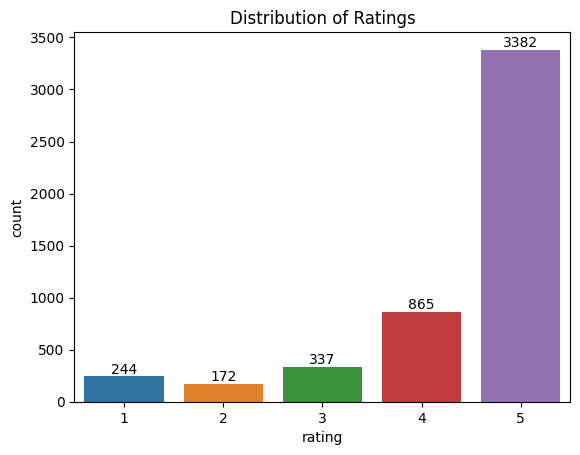

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

ax = sns.countplot(x='rating', data=reviews_df)

for container in ax.containers:
    ax.bar_label(container)

plt.title('Distribution of Ratings')

plt.show()

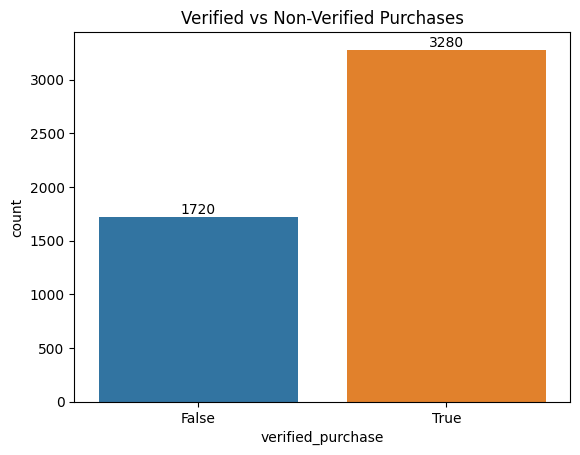

In [46]:
ax = sns.countplot(x='verified_purchase', data=reviews_df)

for container in ax.containers:
    ax.bar_label(container)

plt.title('Verified vs Non-Verified Purchases')

plt.show()

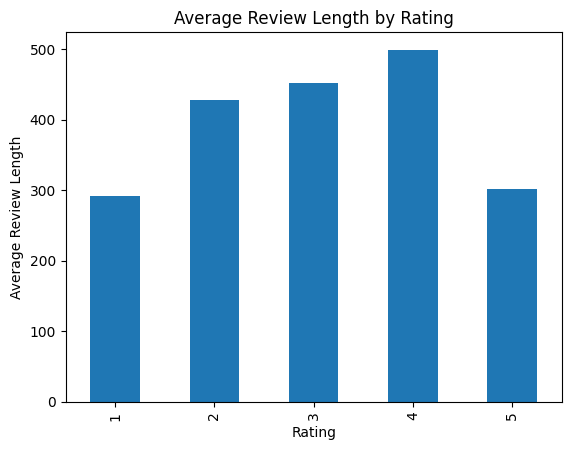

In [49]:
avg_length = reviews_df.groupby('rating')['review_length'].mean()

avg_length.plot(kind='bar')

plt.title('Average Review Length by Rating')
plt.xlabel('Rating')
plt.ylabel('Average Review Length')

plt.show()

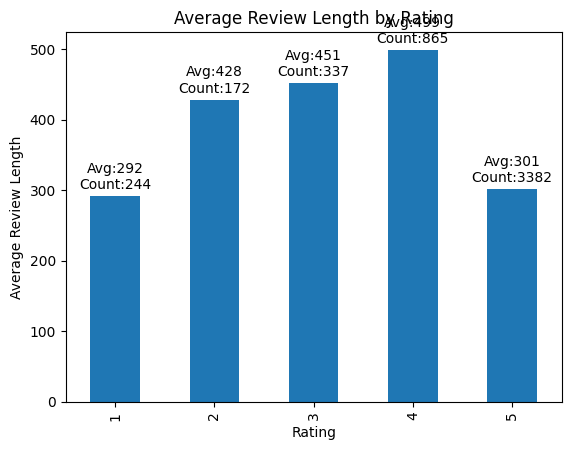

In [50]:
avg_length = reviews_df.groupby('rating')['review_length'].mean()
rating_count = reviews_df['rating'].value_counts().sort_index()

ax = avg_length.plot(kind='bar')

for i, value in enumerate(avg_length):
    plt.text(i, value + 10,
             f'Avg:{value:.0f}\nCount:{rating_count[i+1]}',
             ha='center')

plt.title('Average Review Length by Rating')
plt.xlabel('Rating')
plt.ylabel('Average Review Length')

plt.show()

In [51]:
!pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


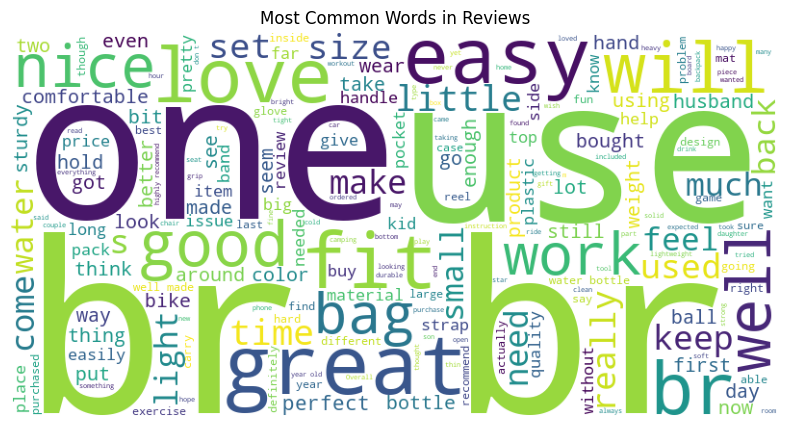

In [52]:
from wordcloud import WordCloud

text = " ".join(reviews_df['text'].dropna())

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis('off')

plt.title('Most Common Words in Reviews')

plt.show()

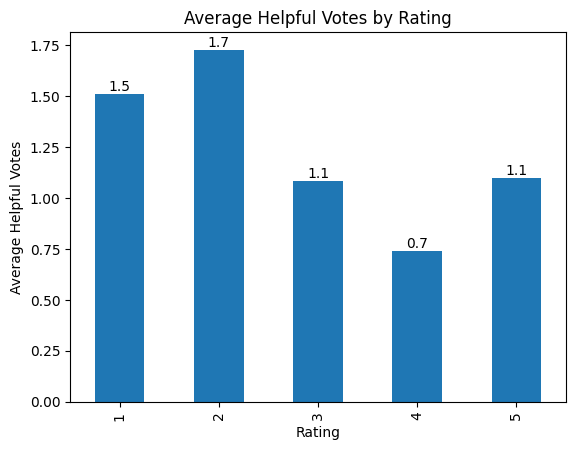

In [53]:
avg_helpful = reviews_df.groupby('rating')['helpful_vote'].mean()

ax = avg_helpful.plot(kind='bar')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f')

plt.title('Average Helpful Votes by Rating')
plt.xlabel('Rating')
plt.ylabel('Average Helpful Votes')

plt.show()

In [54]:
positive_text = " ".join(
    reviews_df[reviews_df['rating'] >= 4]['text'].dropna()
)

In [55]:
negative_text = " ".join(
    reviews_df[reviews_df['rating'] <= 2]['text'].dropna()
)

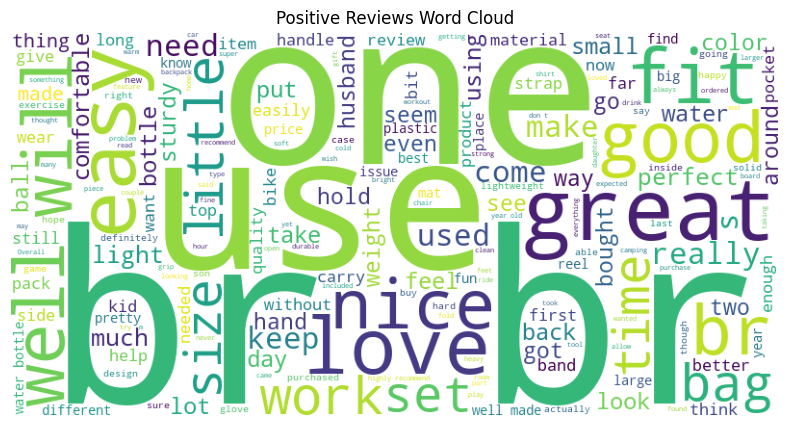

In [56]:
positive_wc = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_text)

plt.figure(figsize=(10,5))

plt.imshow(positive_wc)

plt.axis('off')

plt.title('Positive Reviews Word Cloud')

plt.show()

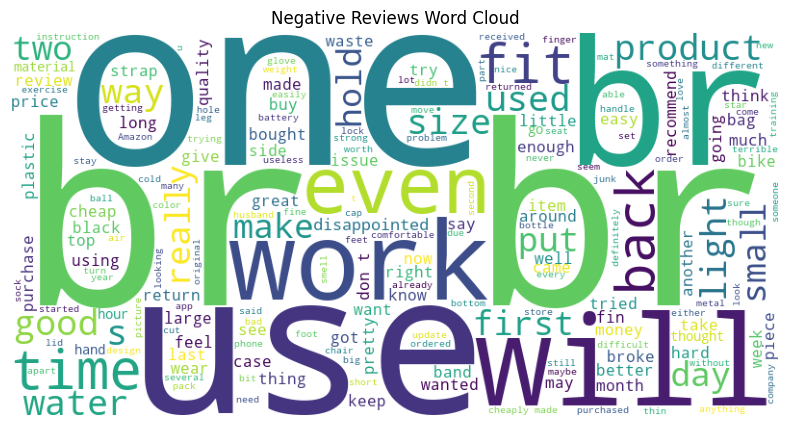

In [57]:
negative_wc = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(negative_text)

plt.figure(figsize=(10,5))

plt.imshow(negative_wc)

plt.axis('off')

plt.title('Negative Reviews Word Cloud')

plt.show()